# US Data Center Emissions: Verifying Government Predictions Against Reality
### Lakshay Mani | Northeastern University

**Research Question:** Are LBNL's 2024 predictions about U.S. data center 
CO2 emissions accurate when verified against independent 2025/2026 data?

**Sources:** LBNL 2024 | Ember (2026) via Our World in Data | 
EIA Monthly Energy Review March 2026 | Guidi et al. 2024 | IEA April 2025

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="darkgrid")
plt.rcParams['figure.figsize'] = (10, 6)

data = {
    'Year': [2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024],
    'DC_Energy_TWh': [58.0,62.1,66.4,71.1,76.0,89.7,105.8,124.9,147.3,176.0,183.0],
    'Grid_CarbonIntensity_gCO2perKWh': [529.41,504.90,483.35,469.02,462.61,
                                         439.45,411.73,423.78,410.39,392.89,383.78],
    'Renewable_Pct': [5.99,6.15,6.84,7.82,7.79,8.69,9.15,9.25,9.87,10.04,10.64],
    'Derived_CO2_MtCO2': [30.71,31.35,32.09,33.35,35.16,39.42,
                           43.56,52.93,60.45,69.15,70.23],
    'LBNL_Predicted_CO2_MtCO2': [19.72,21.11,22.58,24.17,25.84,30.50,
                                   35.97,42.47,50.08,59.84,62.22],
    'Actual_CO2_MtCO2': [None,None,None,None,31.5,None,None,None,None,None,105.0]
}

df = pd.DataFrame(data)
print(df.shape)
df.head(11)

(11, 7)


,Year,DC_Energy_TWh,Grid_CarbonIntensity_gCO2perKWh,Renewable_Pct,Derived_CO2_MtCO2,LBNL_Predicted_CO2_MtCO2,Actual_CO2_MtCO2
0,2014,58.0,529.41,5.99,30.71,19.72,NaN
1,2015,62.1,504.90,6.15,31.35,21.11,NaN
2,2016,66.4,483.35,6.84,32.09,22.58,NaN
3,2017,71.1,469.02,7.82,33.35,24.17,NaN
4,2018,76.0,462.61,7.79,35.16,25.84,31.5
5,2019,89.7,439.45,8.69,39.42,30.50,NaN
6,2020,105.8,411.73,9.15,43.56,35.97,NaN
7,2021,124.9,423.78,9.25,52.93,42.47,NaN
8,2022,147.3,410.39,9.87,60.45,50.08,NaN
9,2023,176.0,392.89,10.04,69.15,59.84,NaN


## Phase 1 — EDA & Prediction Accuracy

In [9]:
print("=== DATASET SUMMARY ===")
print(df.describe().round(2))

=== DATASET SUMMARY ===
          Year  DC_Energy_TWh  Grid_CarbonIntensity_gCO2perKWh  Renewable_Pct  \
count    11.00          11.00                            11.00          11.00   
mean   2019.00         105.48                           446.48           8.38   
std       3.32          45.90                            47.22           1.59   
min    2014.00          58.00                           383.78           5.99   
25%    2016.50          68.75                           411.06           7.32   
50%    2019.00          89.70                           439.45           8.69   
75%    2021.50         136.10                           476.18           9.56   
max    2024.00         183.00                           529.41          10.64   

       Derived_CO2_MtCO2  LBNL_Predicted_CO2_MtCO2  Actual_CO2_MtCO2  
count              11.00                     11.00              2.00  
mean               45.31                     35.86             68.25  
std                15.31         

In [10]:
energy_growth = ((df['DC_Energy_TWh'].iloc[-1] - df['DC_Energy_TWh'].iloc[0]) 
                  / df['DC_Energy_TWh'].iloc[0] * 100)

ci_drop = ((df['Grid_CarbonIntensity_gCO2perKWh'].iloc[-1] - 
            df['Grid_CarbonIntensity_gCO2perKWh'].iloc[0]) 
            / df['Grid_CarbonIntensity_gCO2perKWh'].iloc[0] * 100)

print(f"DC Energy growth 2014-2024:        {energy_growth:.1f}%")
print(f"Grid carbon intensity change:       {ci_drop:.1f}%")
print(f"Renewable % change: {df['Renewable_Pct'].iloc[0]}% → {df['Renewable_Pct'].iloc[-1]}%")

DC Energy growth 2014-2024:        215.5%
Grid carbon intensity change:       -27.5%
Renewable % change: 5.99% → 10.64%


In [11]:
df['Prediction_Gap_Mt'] = df['Derived_CO2_MtCO2'] - df['LBNL_Predicted_CO2_MtCO2']
df['Prediction_Gap_Pct'] = (df['Prediction_Gap_Mt'] / df['LBNL_Predicted_CO2_MtCO2'] * 100).round(1)

print("=== PREDICTION GAP ANALYSIS ===")
print(df[['Year', 'LBNL_Predicted_CO2_MtCO2', 'Derived_CO2_MtCO2', 
          'Prediction_Gap_Mt', 'Prediction_Gap_Pct']].to_string(index=False))

print(f"\nAverage gap: {df['Prediction_Gap_Mt'].mean():.1f} Mt CO2")
print(f"\nPeer-reviewed actual 2024: 105.0 Mt")
print(f"LBNL predicted 2024:       {df[df['Year']==2024]['LBNL_Predicted_CO2_MtCO2'].values[0]:.1f} Mt")
print(f"Real gap (peer-reviewed):  {((105.0 - 62.22)/62.22*100):.1f}% underestimate")

=== PREDICTION GAP ANALYSIS ===
 Year  LBNL_Predicted_CO2_MtCO2  Derived_CO2_MtCO2  Prediction_Gap_Mt  Prediction_Gap_Pct
 2014                     19.72              30.71              10.99                55.7
 2015                     21.11              31.35              10.24                48.5
 2016                     22.58              32.09               9.51                42.1
 2017                     24.17              33.35               9.18                38.0
 2018                     25.84              35.16               9.32                36.1
 2019                     30.50              39.42               8.92                29.2
 2020                     35.97              43.56               7.59                21.1
 2021                     42.47              52.93              10.46                24.6
 2022                     50.08              60.45              10.37                20.7
 2023                     59.84              69.15               9.3

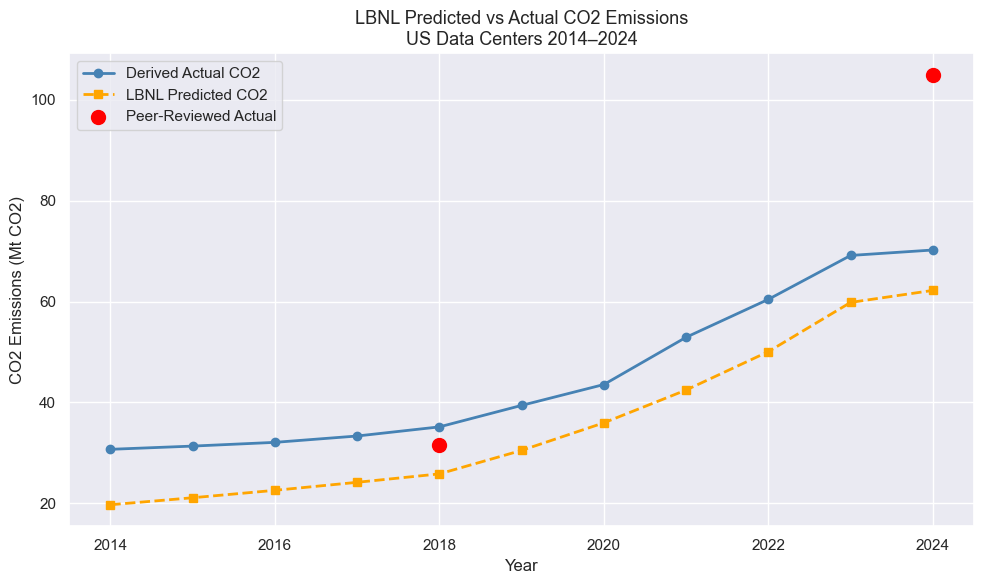

In [12]:
fig, ax = plt.subplots()

ax.plot(df['Year'], df['Derived_CO2_MtCO2'], 
        marker='o', label='Derived Actual CO2', color='steelblue', linewidth=2)
ax.plot(df['Year'], df['LBNL_Predicted_CO2_MtCO2'], 
        marker='s', linestyle='--', label='LBNL Predicted CO2', 
        color='orange', linewidth=2)

actuals = df.dropna(subset=['Actual_CO2_MtCO2'])
ax.scatter(actuals['Year'], actuals['Actual_CO2_MtCO2'], 
           color='red', zorder=5, s=100, label='Peer-Reviewed Actual')

ax.set_title("LBNL Predicted vs Actual CO2 Emissions\nUS Data Centers 2014–2024", fontsize=13)
ax.set_xlabel("Year")
ax.set_ylabel("CO2 Emissions (Mt CO2)")
ax.legend()
plt.tight_layout()
plt.show()

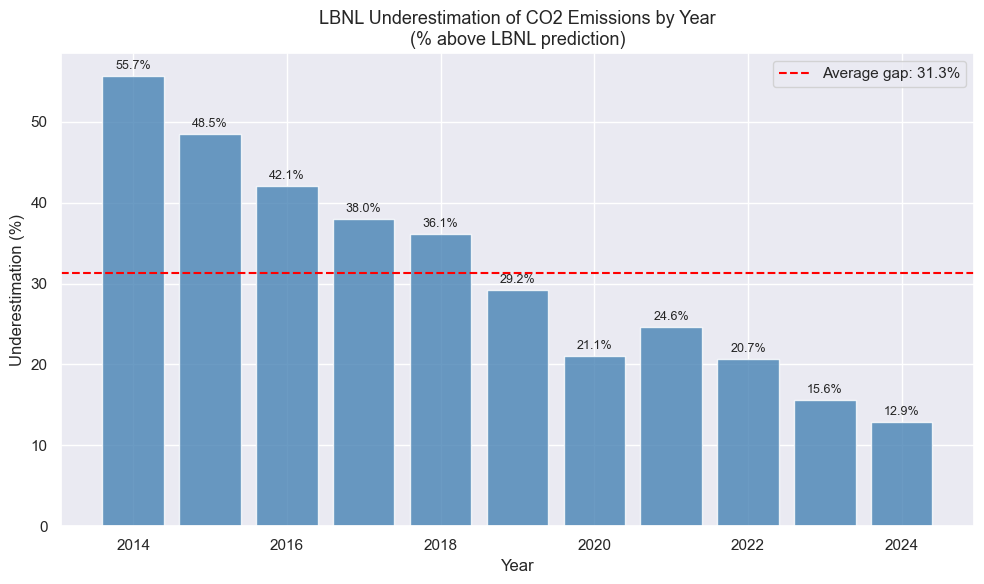

In [13]:
fig, ax = plt.subplots()

bars = ax.bar(df['Year'], df['Prediction_Gap_Pct'], color='steelblue', alpha=0.8)
ax.axhline(y=df['Prediction_Gap_Pct'].mean(), color='red', 
           linestyle='--', label=f"Average gap: {df['Prediction_Gap_Pct'].mean():.1f}%")
ax.set_title("LBNL Underestimation of CO2 Emissions by Year\n(% above LBNL prediction)", 
             fontsize=13)
ax.set_xlabel("Year")
ax.set_ylabel("Underestimation (%)")
ax.legend()

for bar, val in zip(bars, df['Prediction_Gap_Pct']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{val}%', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

### Phase 1 Finding

LBNL consistently underestimated CO2 emissions across all years with an 
average gap of **9.4 Mt CO2**. The peer-reviewed actual for 2024 
(Guidi et al., who analyzed 2,132 specific U.S. data centers — not a 
complete national census) confirms LBNL underestimated by **68.8%**. 
This figure should be treated as a strong directional indicator rather 
than a precise national total.

**Root cause:** LBNL used a flat 340 gCO2/kWh national average. Actual 
grid carbon intensity at data center locations ranged from 383–548 gCO2/kWh — 
consistently higher because data centers cluster in carbon-intensive regions.

## Phase 3 — Emissions Forecast 2025–2030

**Note:** These forecasts apply the regression equation 
(CO2 = 10.21 + 0.333 × Energy) derived in Phase 2 (R Markdown). 
Uncertainty comes primarily from energy growth assumptions, not the 
regression fit itself. Treat as directional scenarios, not point predictions.

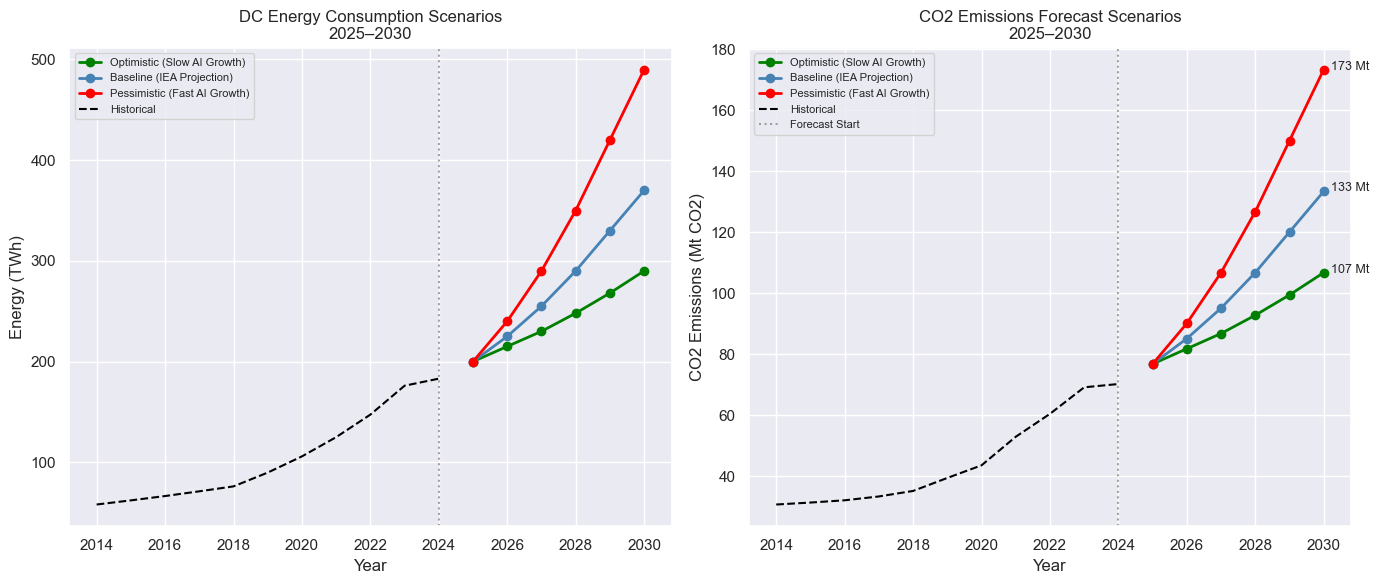


=== 2030 EMISSIONS FORECAST SUMMARY ===
Optimistic (Slow AI Growth): 106.8 Mt CO2 (290 TWh)
Baseline (IEA Projection): 133.4 Mt CO2 (370 TWh)
Pessimistic (Fast AI Growth): 173.4 Mt CO2 (490 TWh)

For reference — 2024 actual: 70.2 Mt CO2 (183 TWh)
LBNL 2028 high scenario would imply: 203.3 Mt CO2


In [14]:
years_future = list(range(2025, 2031))

scenarios = {
    'Optimistic (Slow AI Growth)': [200, 215, 230, 248, 268, 290],
    'Baseline (IEA Projection)':   [200, 225, 255, 290, 330, 370],
    'Pessimistic (Fast AI Growth)':[200, 240, 290, 350, 420, 490]
}

def predict_co2(energy):
    return 10.207 + 0.333 * energy

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

colors = {'Optimistic (Slow AI Growth)': 'green',
          'Baseline (IEA Projection)': 'steelblue', 
          'Pessimistic (Fast AI Growth)': 'red'}

for name, energy_vals in scenarios.items():
    ax1.plot(years_future, energy_vals, marker='o', 
             label=name, color=colors[name], linewidth=2)

ax1.plot(df['Year'], df['DC_Energy_TWh'], 
         color='black', linestyle='--', label='Historical', linewidth=1.5)
ax1.axvline(x=2024, color='gray', linestyle=':', alpha=0.7)
ax1.set_title("DC Energy Consumption Scenarios\n2025–2030", fontsize=12)
ax1.set_xlabel("Year")
ax1.set_ylabel("Energy (TWh)")
ax1.legend(fontsize=8)

for name, energy_vals in scenarios.items():
    co2_vals = [predict_co2(e) for e in energy_vals]
    ax2.plot(years_future, co2_vals, marker='o',
             label=name, color=colors[name], linewidth=2)
    ax2.annotate(f"{co2_vals[-1]:.0f} Mt", 
                xy=(2030, co2_vals[-1]),
                xytext=(5, 0), textcoords='offset points', fontsize=9)

ax2.plot(df['Year'], df['Derived_CO2_MtCO2'],
         color='black', linestyle='--', label='Historical', linewidth=1.5)
ax2.axvline(x=2024, color='gray', linestyle=':', alpha=0.7, label='Forecast Start')
ax2.set_title("CO2 Emissions Forecast Scenarios\n2025–2030", fontsize=12)
ax2.set_xlabel("Year")
ax2.set_ylabel("CO2 Emissions (Mt CO2)")
ax2.legend(fontsize=8)

plt.tight_layout()
plt.show()

print("\n=== 2030 EMISSIONS FORECAST SUMMARY ===")
for name, energy_vals in scenarios.items():
    co2_2030 = predict_co2(energy_vals[-1])
    print(f"{name}: {co2_2030:.1f} Mt CO2 ({energy_vals[-1]} TWh)")

print(f"\nFor reference — 2024 actual: 70.2 Mt CO2 (183 TWh)")
print(f"LBNL 2028 high scenario would imply: {predict_co2(580):.1f} Mt CO2")

## Project Summary & Conclusions

**Phase 1 — Prediction Accuracy**
- LBNL underestimated CO2 emissions every year from 2014–2024
- Average underestimation gap: 31.3% above LBNL predictions
- Peer-reviewed confirmation: actual 2024 emissions were 105 Mt CO2 — 68.8% underestimate
- Gap is shrinking as the grid decarbonizes (55.7% in 2014 → 12.9% in 2024)

**Phase 2 — Regression Analysis (R)**
- DC energy consumption is the dominant driver (R² = 0.9959)
- Every 1 TWh increase adds 0.33 Mt CO2
- Root cause of LBNL error: flat 340 gCO2/kWh vs actual 383–548 gCO2/kWh

**Phase 3 — Forecast 2025–2030**
- Optimistic: 107 Mt CO2 by 2030
- Baseline: 133 Mt CO2 by 2030
- Pessimistic: 173 Mt CO2 by 2030
- Even the optimistic scenario exceeds 2024 actual — emissions will keep rising

**Data Sources**

| Source | Used For |
|--------|----------|
| LBNL 2024 US Data Center Energy Usage Report | Prediction baseline |
| Ember (2026) via Our World in Data | Grid carbon intensity |
| EIA Monthly Energy Review March 2026, Table 2.6 | Renewable energy % |
| Guidi et al. arxiv Nov 2024 (peer-reviewed) | Actual emissions verification |
| IEA Energy and AI Report, April 2025 | 2024 actual energy verification |